# Minecraft CTF Live Play

Run cells top-to-bottom: `Config` -> `Utils` -> `Run`.

In [1]:
from datetime import datetime
from pathlib import Path

# ---- Config ----
TEAM_NUM = 52
PLAYER_NUM = 2
AGAINST_TEAM = None  # Example: 1, 2, ... or None for debug mode
PER_TEAM_PLAYER = 1
MAP_MODE = "fixed"  # "fixed" or "random"
SERVER = "10.31.0.101"
PORT = 25565
# 改成你的STRATEGY
#STRATEGY = "student_strategy.RandomWalkStrategy"
STRATEGY = "default_strategy.PickClosestFlagAndBackStrategy"
ACTION_TICK_SECONDS = 0.10
SNAPSHOT_TICK_SECONDS = 0.50
DISPLAY_ID = "ctf-live-map"

print(f" Bot: CTF-{TEAM_NUM}-{PLAYER_NUM}\n 策略: {STRATEGY}\n 对手组: {AGAINST_TEAM}\n 地图模式: {MAP_MODE}")

 Bot: CTF-52-2
 策略: default_strategy.PickClosestFlagAndBackStrategy
 对手组: None
 地图模式: fixed


In [2]:
import importlib
import json
import time

from IPython.display import display, update_display

from lib.world import JavaScriptBridge, World, _build_dynamic_delta, _build_dynamic_state
from render import render_observation

JS_PRELOAD_MODULES = (
    "mineflayer",
    "mineflayer-pathfinder",
    "vec3",
    "minecraft-data",
    "node:vm",
)


def _initialize_js_bridge() -> tuple[object, JavaScriptBridge]:
    try:
        import javascript
        from javascript import On, off, require, once
    except Exception as exc:
        raise RuntimeError(
            "Unable to initialize the Python JavaScript bridge. "
            "Install/configure the `javascript` package and Mineflayer dependencies first. "
            f"Root cause: {type(exc).__name__}: {exc}"
        ) from exc

    try:
        require("node:vm")
    except Exception:
        try:
            javascript.terminate()
        except Exception:
            pass
        try:
            javascript.init()
            from javascript import On, off, require, once
        except Exception as exc:
            raise RuntimeError(
                "Unable to initialize the Python JavaScript bridge. "
                "Install/configure the `javascript` package and Mineflayer dependencies first. "
                f"Root cause: {type(exc).__name__}: {exc}"
            ) from exc

    for module_name in JS_PRELOAD_MODULES:
        require(module_name)

    return javascript, JavaScriptBridge(require=require, once=once, On=On, off=off)


def _load_strategy(qualified_name: str):
    module_name, _, attribute_name = qualified_name.rpartition(".")
    if not module_name or not attribute_name:
        raise ValueError(
            f"Invalid strategy {qualified_name!r}. Expected format module_name.ClassName."
        )
    module = importlib.import_module(module_name)
    strategy_cls = getattr(module, attribute_name)
    return strategy_cls()


def _timestamp_text(epoch_seconds: float) -> str:
    seconds = int(epoch_seconds)
    milliseconds = int((epoch_seconds - seconds) * 1000)
    return time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(epoch_seconds)) + f".{milliseconds:03d}"


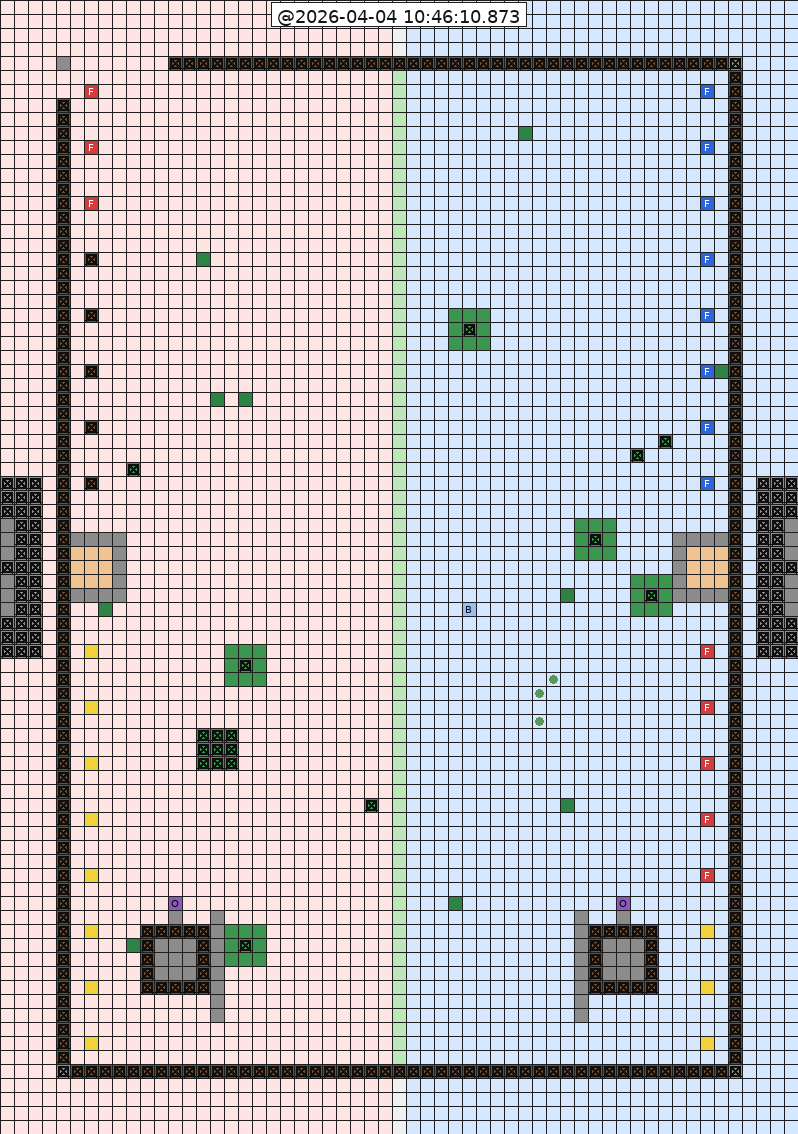

Wrote final observation to logs/2026-04-04_10:43:08-final-shot.json
Appended snapshots to logs/2026-04-04_10:43:08-multi-shot.jsonl






































































































































































































































































































































































































































































































































































































































































































































































































































































































In [3]:
# ---- Run Strategy ----
RUN_TS = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
LOG_DIR = Path("logs")
MULTI_LOG_PATH = LOG_DIR / f"{RUN_TS}-multi-shot.jsonl"
FINAL_SHOT_PATH = LOG_DIR / f"{RUN_TS}-final-shot.json"
MULTI_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
MULTI_LOG_PATH.write_text("", encoding="utf-8")

previous_dynamic_state = None
next_snapshot_at = 0.0
display_started = False
session_started = False
session_ended = False
javascript_runtime = None
world = None

try:
    javascript_runtime, js_bridge = _initialize_js_bridge()
    mineflayer = js_bridge.require("mineflayer")
    world = World(
        js_bridge=js_bridge,
        team_num=TEAM_NUM,
        player_num=PLAYER_NUM,
        against_team=AGAINST_TEAM,
        total_player_per_team=PER_TEAM_PLAYER,
        map_mode=MAP_MODE,
        server=SERVER,
        port=PORT,
    )
    strategy = _load_strategy(STRATEGY)

    world._active_log_path = MULTI_LOG_PATH
    world.join_the_world()
    current_observation = world._ready_observation or world.observe()
    strategy.on_game_start(current_observation)

    world._append_log_line(
        MULTI_LOG_PATH,
        {
            "event": "session_start",
            "timestamp": time.time(),
            "bot_name": world.bot_name,
            "team": current_observation.team,
            "action_tick_seconds": ACTION_TICK_SECONDS,
            "snapshot_tick_seconds": SNAPSHOT_TICK_SECONDS,
        },
    )
    session_started = True

    while not world.game_ended:
        try:
            delta_snapshot = world.quick_observe()
            current_observation.patch_observation(delta_snapshot).validate()
        except Exception as exc:
            print(f"quick_observe() failed ({exc}); falling back to full observe().")
            current_observation = world.observe()
            world._last_quick_snapshot = None

        actions = strategy.compute_next_action(current_observation)
        try:
            world.execute_actions(actions)
        except Exception:
            pass

        now = time.monotonic()
        if now >= next_snapshot_at:
            frame_timestamp = time.time()
            current_dynamic_state = _build_dynamic_state(current_observation, actions)
            delta_payload = _build_dynamic_delta(previous_dynamic_state, current_dynamic_state)
            world._append_log_line(
                MULTI_LOG_PATH,
                {
                    "timestamp": frame_timestamp,
                    "bot_name": world.bot_name,
                    **delta_payload,
                },
            )
            previous_dynamic_state = current_dynamic_state

            frame = render_observation(
                current_observation,
                timestamp_text=_timestamp_text(frame_timestamp),
            )
            if not display_started:
                display(frame, display_id=DISPLAY_ID)
                display_started = True
            else:
                update_display(frame, display_id=DISPLAY_ID)

            next_snapshot_at = now + SNAPSHOT_TICK_SECONDS

        time.sleep(ACTION_TICK_SECONDS)

    if session_started:
        world._append_log_line(
            MULTI_LOG_PATH,
            {
                "event": "session_end",
                "timestamp": time.time(),
                "bot_name": world.bot_name,
                "team": world.team,
            },
        )
        session_ended = True
except KeyboardInterrupt:
    print("Interrupted by user; stopping and saving final snapshot.")
finally:
    if world is not None:
        try:
            world.stop_actions()
        except Exception:
            pass

        if session_started and not session_ended:
            world._append_log_line(
                MULTI_LOG_PATH,
                {
                    "event": "session_end",
                    "timestamp": time.time(),
                    "bot_name": world.bot_name,
                    "team": world.team,
                },
            )

        final_observation = None
        try:
            final_observation = world.observe()
        except Exception as exc:
            print(f"Failed to capture final observation: {exc}")

        if final_observation is not None:
            FINAL_SHOT_PATH.parent.mkdir(parents=True, exist_ok=True)
            FINAL_SHOT_PATH.write_text(
                json.dumps(final_observation.to_dict(), indent=2),
                encoding="utf-8",
            )
            print(f"Wrote final observation to {FINAL_SHOT_PATH}")

        world.close()
        print(f"Appended snapshots to {MULTI_LOG_PATH}")

    if javascript_runtime is not None:
        try:
            javascript_runtime.terminate()
        except Exception:
            pass


In [ ]:
# JS bridge probe moved into the run cell above.
